In [1]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

In [2]:
import torch
import numpy as np

print(torch.__version__)
print(np.__version__)

2.5.1+cu121
1.26.4


Sequential Time: 10.43750548362732
Parallel Time: 0.19675636291503906
Speedup: 53.04786757079015


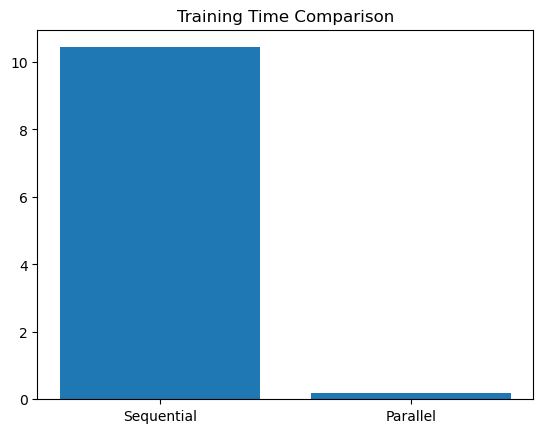

In [3]:
import sys, os, time, torch
import torch.multiprocessing as mp
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import matplotlib.pyplot as plt


device = torch.device("cpu")


transform = transforms.ToTensor()
dataset = datasets.MNIST(root="../data/raw", train=True, download=True, transform=transform)


class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(28*28, 10)

    def forward(self, x):
        return self.linear(x.view(-1, 28*28))


def train_sequential():
    model = SimpleModel()
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()

    start = time.time()

    for x, y in loader:
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

    return time.time() - start


def split_dataset(dataset, n):
    length = len(dataset)
    size = length // n
    return [Subset(dataset, range(i*size, (i+1)*size)) for i in range(n)]


def worker(subset, return_dict, idx):
    model = SimpleModel()
    loader = DataLoader(subset, batch_size=64, shuffle=True)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()

    for x, y in loader:
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

    return_dict[idx] = model.state_dict()


def train_parallel(num_proc=2):
    subsets = split_dataset(dataset, num_proc)

    manager = mp.Manager()
    return_dict = manager.dict()

    processes = []
    start = time.time()

    for i, subset in enumerate(subsets):
        p = mp.Process(target=worker, args=(subset, return_dict, i))
        p.start()
        processes.append(p)

    for p in processes:
        p.join()

    return time.time() - start


if __name__ == "__main__":
    mp.set_start_method("spawn", force=True)

    time_seq = train_sequential()
    time_par = train_parallel(num_proc=2)

    print("Sequential Time:", time_seq)
    print("Parallel Time:", time_par)
    print("Speedup:", time_seq / time_par)


    plt.bar(["Sequential", "Parallel"], [time_seq, time_par])
    plt.title("Training Time Comparison")
    plt.savefig("../result/time_comparison.png")
    plt.show()

In [ ]:
8 may 2026


In [5]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [6]:
from model import SimpleModel
from sequential_gd import train_sequential
from parallel_gd import train_parallel
from utils import *

if __name__ == "__main__":

    dataset = load_mnist()

    subsets = split_dataset(dataset, 2)

    model_seq = SimpleModel()

    seq_time = train_sequential(
        model_seq,
        dataset
    )

    print("Sequential Time:", seq_time)

    model_par = SimpleModel()

    par_time, model_par = train_parallel(
        model_par,
        subsets
    )

    print("Parallel Time:", par_time)

    speedup = calculate_speedup(
        seq_time,
        par_time
    )

    efficiency = calculate_efficiency(
        speedup,
        2
    )

    print("Speedup:", speedup)

    print("Efficiency:", efficiency)

    metrics = {
        "Sequential Time": seq_time,
        "Parallel Time": par_time,
        "Speedup": speedup,
        "Efficiency": efficiency
    }

    save_metrics(metrics)

    plot_results(
        ["Sequential", "Parallel"],
        [seq_time, par_time],
        "Execution Time Comparison",
        "Time (seconds)",
        "../result/plots/execution_time.png"
    )

Sequential Epoch 1 Loss: 549.1454
Sequential Epoch 2 Loss: 287.0874
Sequential Time: 37.634300231933594
Parallel Time: 35.74632477760315
Speedup: 1.0528159318776558
Efficiency: 0.5264079659388279


In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

def load_all_datasets(data_path="../data/raw"):

    datasets_dict = {}


    mnist_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    mnist_dataset = datasets.MNIST(
        root=data_path,
        train=True,
        download=True,
        transform=mnist_transform
    )

    datasets_dict["mnist"] = mnist_dataset


    fashion_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    fashion_dataset = datasets.FashionMNIST(
        root=data_path,
        train=True,
        download=True,
        transform=fashion_transform
    )

    datasets_dict["fashion_mnist"] = fashion_dataset


    breast_data = load_breast_cancer()

    X = breast_data.data
    y = breast_data.target

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    breast_dataset = TensorDataset(X, y)

    datasets_dict["breast_cancer"] = breast_dataset

    return datasets_dict


def split_dataset(dataset, num_splits):

    length = len(dataset)

    split_size = length // num_splits

    subsets = []

    for i in range(num_splits):

        start = i * split_size

        if i == num_splits - 1:
            end = length
        else:
            end = (i + 1) * split_size

        subsets.append(
            Subset(dataset, range(start, end))
        )

    return subsets


def calculate_speedup(seq_time, par_time):

    return seq_time / par_time


def calculate_efficiency(speedup, num_processes):

    return speedup / num_processes

In [9]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from model import SimpleModel
from sequential_gd import train_sequential
from parallel_gd import train_parallel
from utils import *


datasets_dict = load_all_datasets()

mnist_dataset = datasets_dict["mnist"]

fashion_dataset = datasets_dict["fashion_mnist"]

breast_dataset = datasets_dict["breast_cancer"]

print("MNIST Size:", len(mnist_dataset))
print("Fashion-MNIST Size:", len(fashion_dataset))
print("Breast Cancer Size:", len(breast_dataset))



mnist_subsets = split_dataset(
    mnist_dataset,
    2
)



model_seq = SimpleModel()

seq_time = train_sequential(
    model_seq,
    mnist_dataset
)

print("\nSequential Time:", seq_time)



model_par = SimpleModel()

par_time, model_par = train_parallel(
    model_par,
    mnist_subsets
)

print("Parallel Time:", par_time)



speedup = calculate_speedup(
    seq_time,
    par_time
)

efficiency = calculate_efficiency(
    speedup,
    2
)

print("\nSpeedup:", speedup)

print("Efficiency:", efficiency)



metrics = {
    "Sequential Time": seq_time,
    "Parallel Time": par_time,
    "Speedup": speedup,
    "Efficiency": efficiency
}

save_metrics(metrics)



plot_results(
    ["Sequential", "Parallel"],
    [seq_time, par_time],
    "Execution Time Comparison",
    "Time (seconds)",
    "../result/plots/execution_time.png"
)

print("\nExperiment Completed Successfully")

MNIST Size: 60000
Fashion-MNIST Size: 60000
Breast Cancer Size: 569
Sequential Epoch 1 Loss: 546.4646
Sequential Epoch 2 Loss: 283.1679

Sequential Time: 37.77479839324951
Parallel Time: 36.787808656692505

Speedup: 1.0268292614482069
Efficiency: 0.5134146307241034

Experiment Completed Successfully


In [13]:
results = []


results.append({
    "Processes": 1,
    "Execution Time": seq_time,
    "Speedup": 1.0,
    "Efficiency": 1.0
})


for num_processes in [2, 3, 4, 5, 6, 7, 8]:

    print(f"\nRunning with {num_processes} processes...")

    subsets = split_dataset(
        mnist_dataset,
        num_processes
    )

    model_par = SimpleModel()

    par_time, _ = train_parallel(
        model_par,
        subsets
    )

    speedup = calculate_speedup(
        seq_time,
        par_time
    )

    efficiency = calculate_efficiency(
        speedup,
        num_processes
    )

    results.append({
        "Processes": num_processes,
        "Execution Time": par_time,
        "Speedup": speedup,
        "Efficiency": efficiency
    })

import pandas as pd

results_df = pd.DataFrame(results)

print("\nFinal Results:\n")

print(results_df)

results_df.to_csv(
    "../result/metrics/final_results.csv",
    index=False
)

print("\nCSV Saved Successfully")


Running with 2 processes...

Running with 3 processes...

Running with 4 processes...

Running with 5 processes...

Running with 6 processes...

Running with 7 processes...

Running with 8 processes...

Final Results:

   Processes  Execution Time   Speedup  Efficiency
0          1       37.774798  1.000000    1.000000
1          2       30.051552  1.257000    0.628500
2          3       25.992655  1.453287    0.484429
3          4       25.208874  1.498472    0.374618
4          5       27.402916  1.378496    0.275699
5          6       39.403584  0.958664    0.159777
6          7       29.215515  1.292970    0.184710
7          8       25.307035  1.492660    0.186582

CSV Saved Successfully


   Processes  Execution Time   Speedup  Efficiency
0          1       37.774798  1.000000    1.000000
1          2       30.051552  1.257000    0.628500
2          3       25.992655  1.453287    0.484429
3          4       25.208874  1.498472    0.374618
4          5       27.402916  1.378496    0.275699
5          6       39.403584  0.958664    0.159777
6          7       29.215515  1.292970    0.184710
7          8       25.307035  1.492660    0.186582


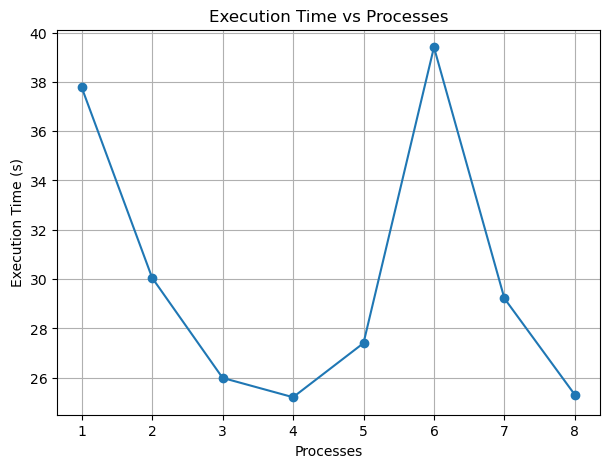

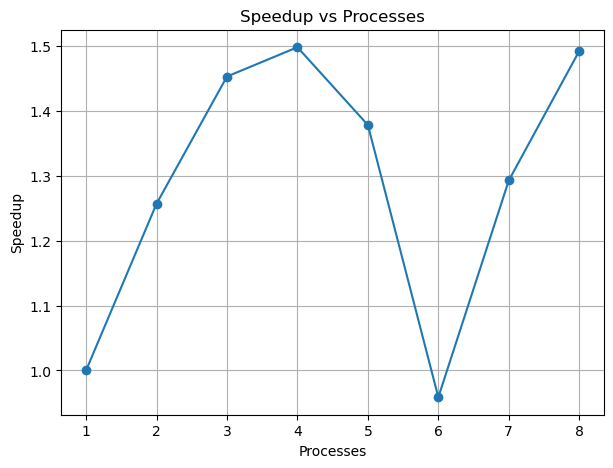

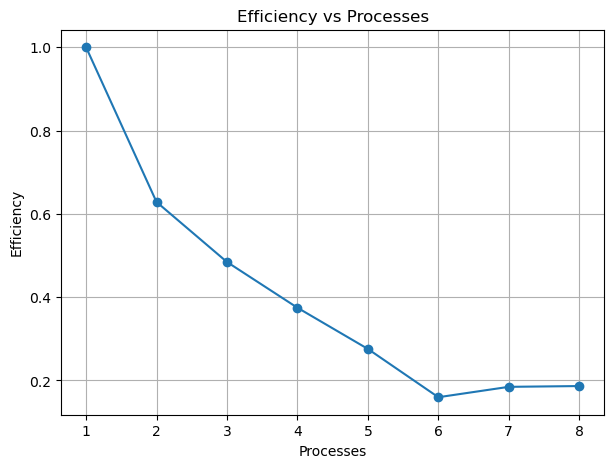


Graphs Generated Successfully


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv(
    "../result/metrics/final_results.csv"
)

print(results_df)


plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Execution Time"],
    marker='o'
)

plt.xlabel("Processes")

plt.ylabel("Execution Time (s)")

plt.title("Execution Time vs Processes")

plt.grid(True)

plt.savefig("../result/plots/execution_time.png")

plt.show()


plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Speedup"],
    marker='o'
)

plt.xlabel("Processes")

plt.ylabel("Speedup")

plt.title("Speedup vs Processes")

plt.grid(True)

plt.savefig("../result/plots/speedup.png")

plt.show()



plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Efficiency"],
    marker='o'
)

plt.xlabel("Processes")

plt.ylabel("Efficiency")

plt.title("Efficiency vs Processes")

plt.grid(True)

plt.savefig("../result/plots/efficiency.png")

plt.show()

print("\nGraphs Generated Successfully")

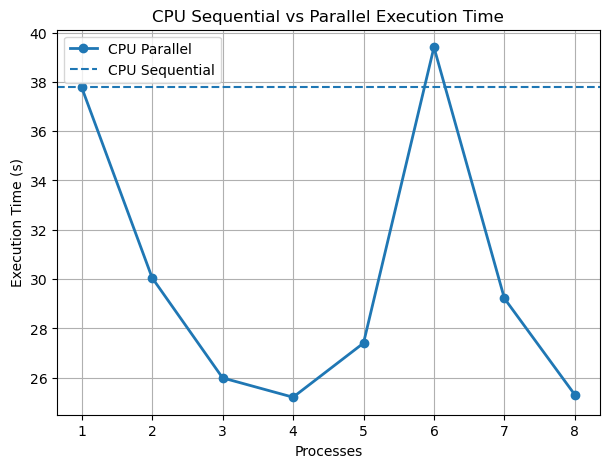

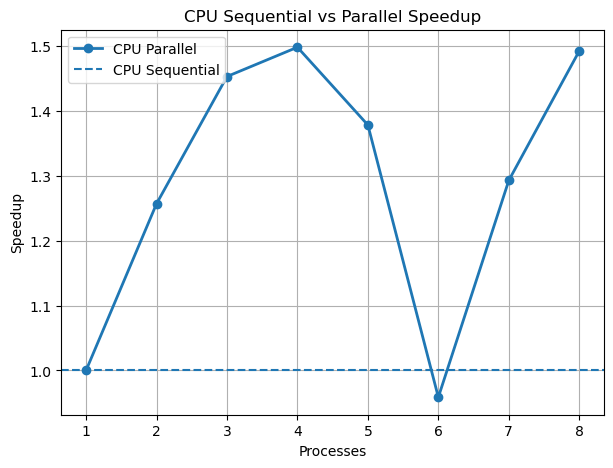

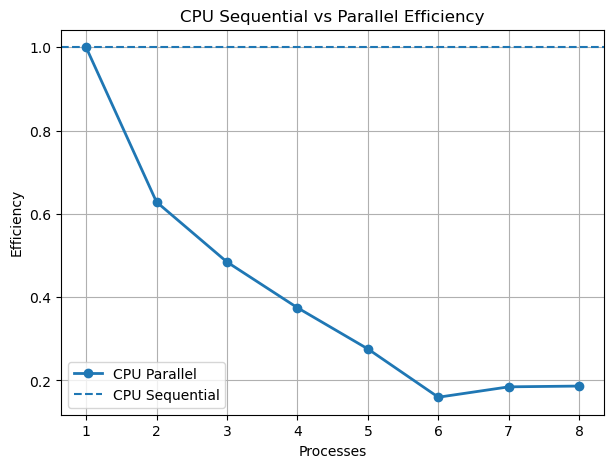

CPU Comparison Graphs Saved Successfully


In [15]:
import matplotlib.pyplot as plt
import os

os.makedirs("../result/plots", exist_ok=True)

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Execution Time"],
    marker='o',
    linewidth=2,
    label="CPU Parallel"
)

plt.axhline(
    y=results_df.loc[
        results_df["Processes"] == 1,
        "Execution Time"
    ].values[0],
    linestyle='--',
    label="CPU Sequential"
)

plt.xlabel("Processes")
plt.ylabel("Execution Time (s)")
plt.title("CPU Sequential vs Parallel Execution Time")
plt.legend()
plt.grid(True)

plt.savefig(
    "../result/plots/cpu_seq_vs_parallel_execution_time.png"
)

plt.show()

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Speedup"],
    marker='o',
    linewidth=2,
    label="CPU Parallel"
)

plt.axhline(
    y=1.0,
    linestyle='--',
    label="CPU Sequential"
)

plt.xlabel("Processes")
plt.ylabel("Speedup")
plt.title("CPU Sequential vs Parallel Speedup")
plt.legend()
plt.grid(True)

plt.savefig(
    "../result/plots/cpu_seq_vs_parallel_speedup.png"
)

plt.show()

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Efficiency"],
    marker='o',
    linewidth=2,
    label="CPU Parallel"
)

plt.axhline(
    y=1.0,
    linestyle='--',
    label="CPU Sequential"
)

plt.xlabel("Processes")
plt.ylabel("Efficiency")
plt.title("CPU Sequential vs Parallel Efficiency")
plt.legend()
plt.grid(True)

plt.savefig(
    "../result/plots/cpu_seq_vs_parallel_efficiency.png"
)

plt.show()

print("CPU Comparison Graphs Saved Successfully")

In [16]:
import torch

print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1650


In [17]:
import torch
from torch.utils.data import DataLoader
import time

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

def train_sequential(model, dataset, epochs=2, lr=0.01):

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=True
    )

    model = model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
    )

    loss_fn = torch.nn.CrossEntropyLoss()

    start_time = time.time()

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            output = model(x)

            loss = loss_fn(output, y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch {epoch+1} Loss: {total_loss:.4f}"
        )

    end_time = time.time()

    total_time = end_time - start_time

    return total_time

In [18]:
import sys
import os
import importlib.util
import torch

sys.path.append(os.path.abspath("../src"))

from model import SimpleModel
from torchvision import datasets, transforms

spec = importlib.util.spec_from_file_location(
    "sequential_gd_1",
    "../src/sequential_gd_1.py"
)

sequential_module = importlib.util.module_from_spec(spec)

spec.loader.exec_module(sequential_module)

train_sequential = sequential_module.train_sequential

print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_dataset = datasets.MNIST(
    root="../data/raw",
    train=True,
    download=True,
    transform=transform
)

model_gpu = SimpleModel()

gpu_time = train_sequential(
    model_gpu,
    mnist_dataset
)

print(gpu_time)

True
NVIDIA GeForce GTX 1650
Epoch 1 Loss: 545.2313
Epoch 2 Loss: 278.3159
26.44084906578064


           Method  Execution Time
0  CPU Sequential       37.774798
1    CPU Parallel       25.208874
2        GPU CUDA       26.440849


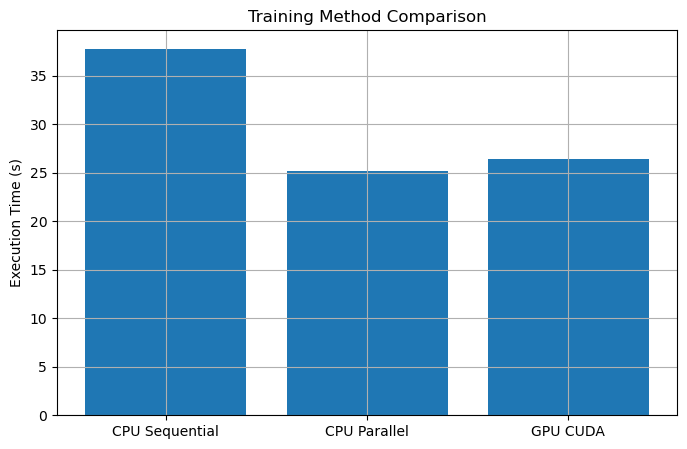

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv(
    "../result/metrics/final_results.csv"
)

gpu_df = pd.DataFrame({
    "Processes": ["GPU CUDA"],
    "Execution Time": [gpu_time]
})

best_parallel_time = results_df["Execution Time"].min()

cpu_seq_time = results_df.loc[
    results_df["Processes"] == 1,
    "Execution Time"
].values[0]

comparison_df = pd.DataFrame({
    "Method": [
        "CPU Sequential",
        "CPU Parallel",
        "GPU CUDA"
    ],
    "Execution Time": [
        cpu_seq_time,
        best_parallel_time,
        gpu_time
    ]
})

print(comparison_df)

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Method"],
    comparison_df["Execution Time"]
)

plt.ylabel("Execution Time (s)")

plt.title("Training Method Comparison")

plt.grid(True)
plt.savefig(
    "../result/plots/Training Method Comparison.png"
)
plt.show()

In [20]:
import sys
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

sys.path.append(os.path.abspath("../src"))

from model import SimpleModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_dataset = datasets.MNIST(
    root="../data/raw",
    train=True,
    download=True,
    transform=transform
)

batch_size = 256

base_loader = DataLoader(
    mnist_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
)

base_model = SimpleModel().to(device)

optimizer = optim.SGD(
    base_model.parameters(),
    lr=0.01
)

loss_fn = nn.CrossEntropyLoss()

start_time = time.time()

base_model.train()

for epoch in range(2):

    for x, y in base_loader:

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        output = base_model(x)

        loss = loss_fn(output, y)

        loss.backward()

        optimizer.step()

seq_time = time.time() - start_time

results = []

results.append({
    "Processes": 1,
    "Execution Time": seq_time,
    "Speedup": 1.0,
    "Efficiency": 1.0
})

for num_processes in [2, 3, 4, 5, 6, 7, 8]:

    lengths = [len(mnist_dataset) // num_processes] * num_processes

    lengths[-1] += len(mnist_dataset) - sum(lengths)

    subsets = random_split(
        mnist_dataset,
        lengths
    )

    parallel_model = nn.DataParallel(
        SimpleModel()
    ).to(device)

    optimizer = optim.SGD(
        parallel_model.parameters(),
        lr=0.01
    )

    start_time = time.time()

    parallel_model.train()

    for subset in subsets:

        loader = DataLoader(
            subset,
            batch_size=batch_size,
            shuffle=True,
            pin_memory=True
        )

        for x, y in loader:

            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()

            output = parallel_model(x)

            loss = loss_fn(output, y)

            loss.backward()

            optimizer.step()

    par_time = time.time() - start_time

    speedup = seq_time / par_time

    efficiency = speedup / num_processes

    results.append({
        "Processes": num_processes,
        "Execution Time": par_time,
        "Speedup": speedup,
        "Efficiency": efficiency
    })

results_df = pd.DataFrame(results)

print(results_df)

results_df.to_csv(
    "../result/metrics/cuda_parallel_results.csv",
    index=False
)

   Processes  Execution Time   Speedup  Efficiency
0          1       28.098803  1.000000    1.000000
1          2       14.014052  2.005045    1.002522
2          3       14.431025  1.947111    0.649037
3          4       14.581478  1.927020    0.481755
4          5       16.074448  1.748042    0.349608
5          6       16.360803  1.717446    0.286241
6          7       14.817625  1.896309    0.270901
7          8       14.785489  1.900431    0.237554


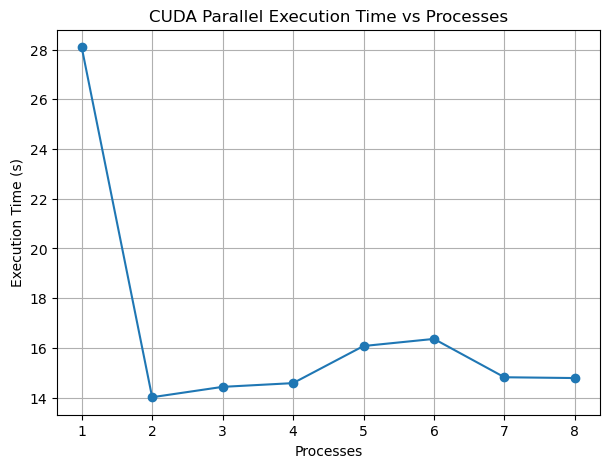

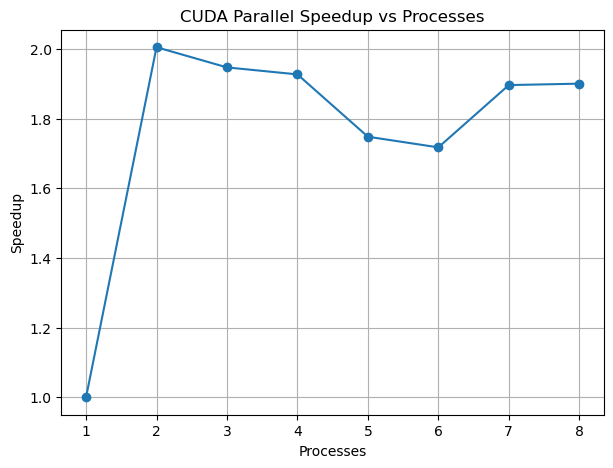

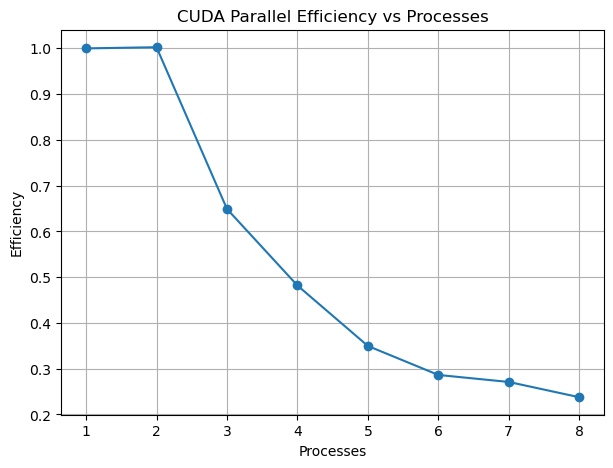

Graphs Saved Successfully


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs("../result/plots", exist_ok=True)

results_df = pd.read_csv(
    "../result/metrics/cuda_parallel_results.csv"
)

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Execution Time"],
    marker='o'
)

plt.xlabel("Processes")

plt.ylabel("Execution Time (s)")

plt.title("CUDA Parallel Execution Time vs Processes")

plt.grid(True)

plt.savefig(
    "../result/plots/cuda_execution_time.png"
)

plt.show()

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Speedup"],
    marker='o'
)

plt.xlabel("Processes")

plt.ylabel("Speedup")

plt.title("CUDA Parallel Speedup vs Processes")

plt.grid(True)

plt.savefig(
    "../result/plots/cuda_speedup.png"
)

plt.show()

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Processes"],
    results_df["Efficiency"],
    marker='o'
)

plt.xlabel("Processes")

plt.ylabel("Efficiency")

plt.title("CUDA Parallel Efficiency vs Processes")

plt.grid(True)

plt.savefig(
    "../result/plots/cuda_efficiency.png"
)

plt.show()

print("Graphs Saved Successfully")

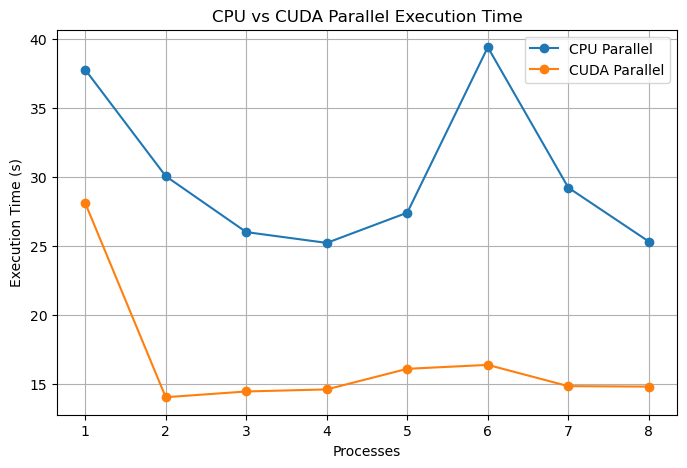

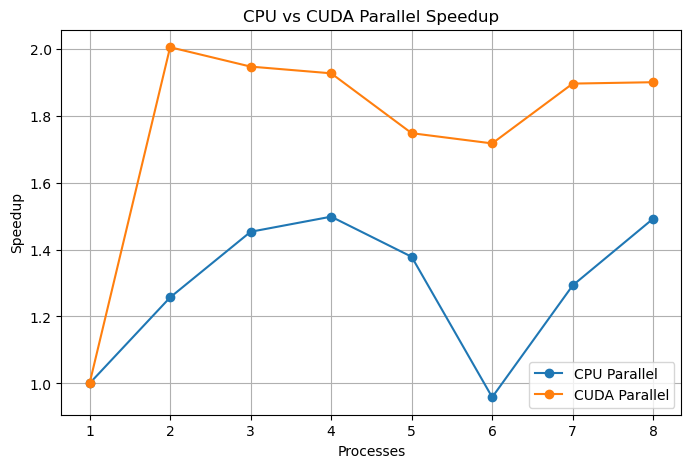

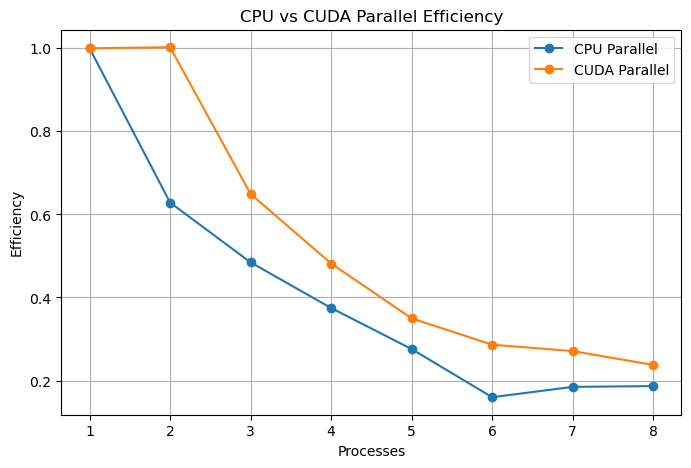

Comparison Graphs Saved Successfully


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../result/plots", exist_ok=True)

cpu_df = pd.read_csv(
    "../result/metrics/final_results.csv"
)

cuda_df = pd.read_csv(
    "../result/metrics/cuda_parallel_results.csv"
)

plt.figure(figsize=(8,5))

plt.plot(
    cpu_df["Processes"],
    cpu_df["Execution Time"],
    marker='o',
    label="CPU Parallel"
)

plt.plot(
    cuda_df["Processes"],
    cuda_df["Execution Time"],
    marker='o',
    label="CUDA Parallel"
)

plt.xlabel("Processes")

plt.ylabel("Execution Time (s)")

plt.title("CPU vs CUDA Parallel Execution Time")

plt.legend()

plt.grid(True)

plt.savefig(
    "../result/plots/cpu_vs_cuda_execution_time.png"
)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    cpu_df["Processes"],
    cpu_df["Speedup"],
    marker='o',
    label="CPU Parallel"
)

plt.plot(
    cuda_df["Processes"],
    cuda_df["Speedup"],
    marker='o',
    label="CUDA Parallel"
)

plt.xlabel("Processes")

plt.ylabel("Speedup")

plt.title("CPU vs CUDA Parallel Speedup")

plt.legend()

plt.grid(True)

plt.savefig(
    "../result/plots/cpu_vs_cuda_speedup.png"
)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    cpu_df["Processes"],
    cpu_df["Efficiency"],
    marker='o',
    label="CPU Parallel"
)

plt.plot(
    cuda_df["Processes"],
    cuda_df["Efficiency"],
    marker='o',
    label="CUDA Parallel"
)

plt.xlabel("Processes")

plt.ylabel("Efficiency")

plt.title("CPU vs CUDA Parallel Efficiency")

plt.legend()

plt.grid(True)

plt.savefig(
    "../result/plots/cpu_vs_cuda_efficiency.png"
)

plt.show()

print("Comparison Graphs Saved Successfully")

            Method  Execution Time
0   CPU Sequential       28.098803
1  CUDA Sequential       26.440849


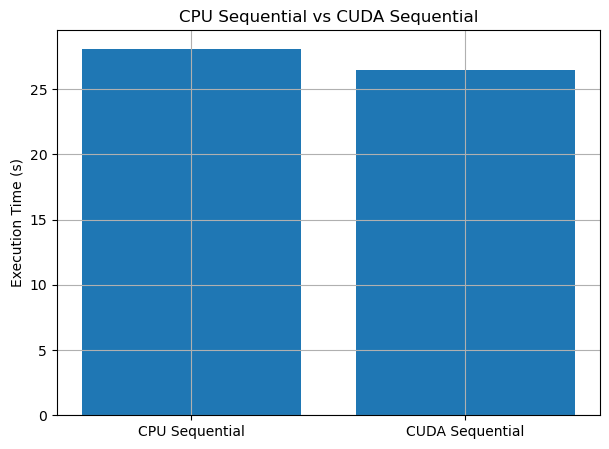

Graph Saved Successfully


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../result/plots", exist_ok=True)

cpu_seq_time = results_df.loc[
    results_df["Processes"] == 1,
    "Execution Time"
].values[0]

comparison_df = pd.DataFrame({
    "Method": [
        "CPU Sequential",
        "CUDA Sequential"
    ],
    "Execution Time": [
        cpu_seq_time,
        gpu_time
    ]
})

print(comparison_df)

plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["Method"],
    comparison_df["Execution Time"]
)

plt.ylabel("Execution Time (s)")

plt.title("CPU Sequential vs CUDA Sequential")

plt.grid(True)

plt.savefig(
    "../result/plots/cpu_seq_vs_cuda_seq.png"
)

plt.show()

print("Graph Saved Successfully")

  Training Method  Execution Time
0  CPU Sequential       37.774798
1    CPU Parallel       25.208874
2  GPU Sequential       26.440849
3    GPU Parallel       14.014052


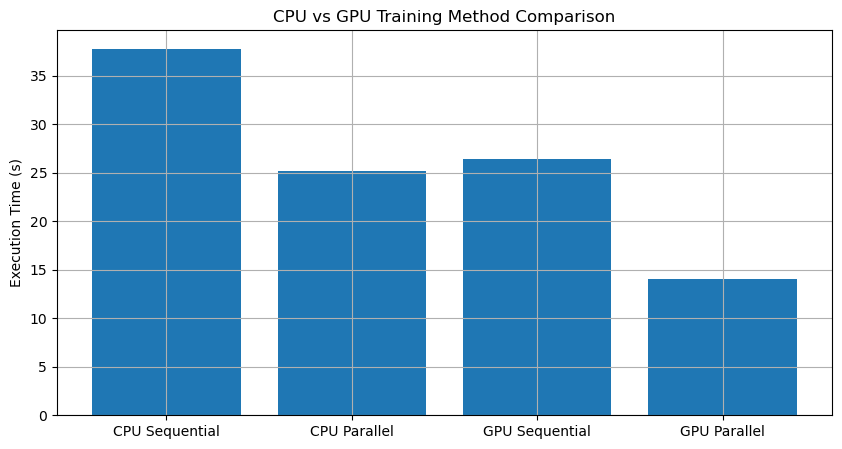

Comparison Graph Saved Successfully


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../result/plots", exist_ok=True)

cpu_df = pd.read_csv(
    "../result/metrics/final_results.csv"
)

cuda_df = pd.read_csv(
    "../result/metrics/cuda_parallel_results.csv"
)

cpu_sequential_time = cpu_df.loc[
    cpu_df["Processes"] == 1,
    "Execution Time"
].values[0]

cpu_parallel_time = cpu_df["Execution Time"].min()

cuda_sequential_time = gpu_time

cuda_parallel_time = cuda_df["Execution Time"].min()

comparison_df = pd.DataFrame({
    "Training Method": [
        "CPU Sequential",
        "CPU Parallel",
        "GPU Sequential",
        "GPU Parallel"
    ],
    "Execution Time": [
        cpu_sequential_time,
        cpu_parallel_time,
        cuda_sequential_time,
        cuda_parallel_time
    ]
})

print(comparison_df)

plt.figure(figsize=(10,5))

plt.bar(
    comparison_df["Training Method"],
    comparison_df["Execution Time"]
)

plt.ylabel("Execution Time (s)")

plt.title("CPU vs GPU Training Method Comparison")

plt.grid(True)

plt.savefig(
    "../result/plots/cpu_gpu_training_comparison.png"
)

plt.show()

print("Comparison Graph Saved Successfully")

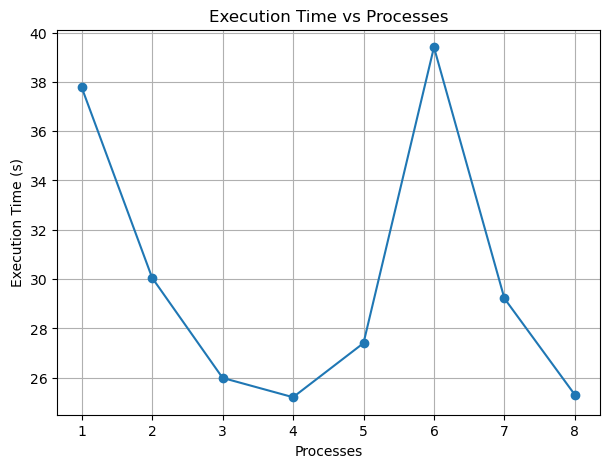

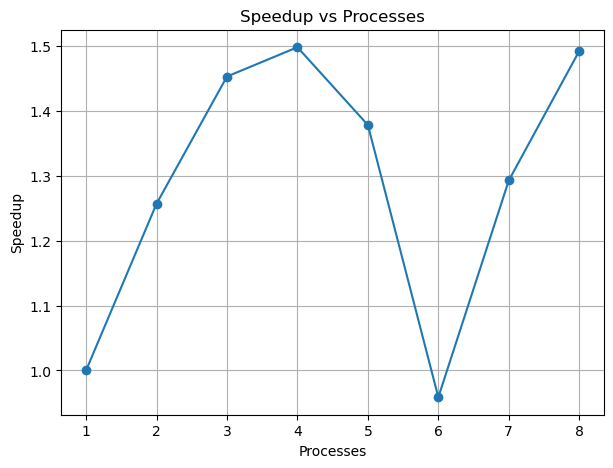

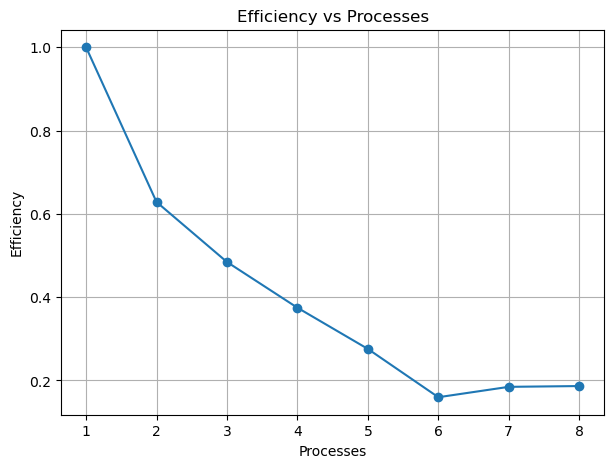

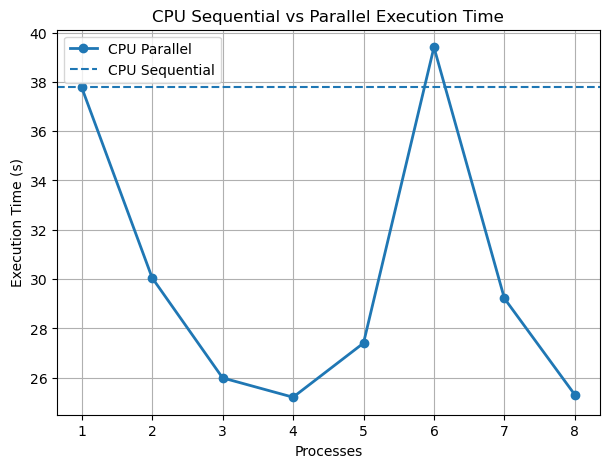

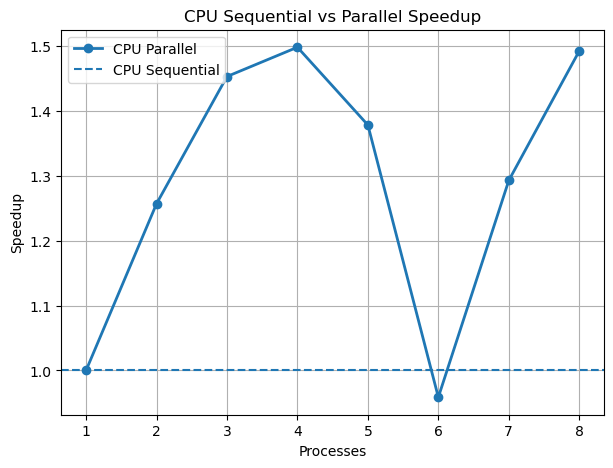

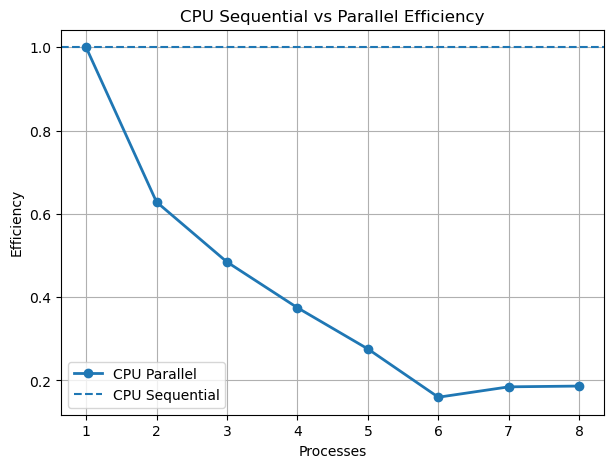

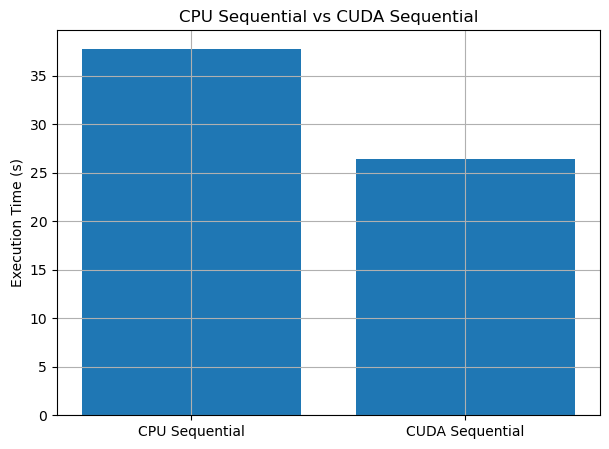

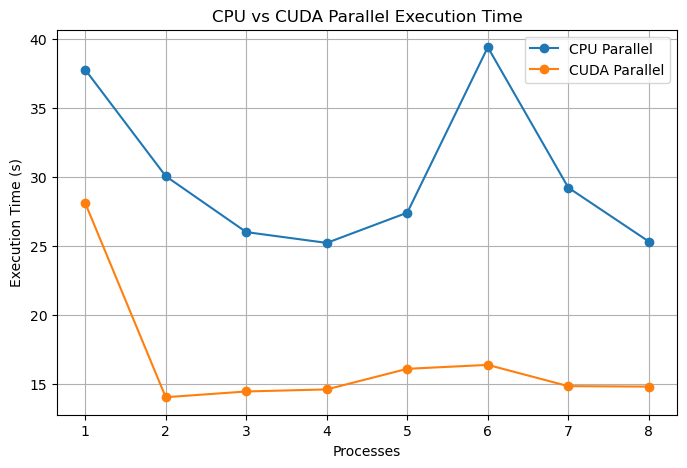

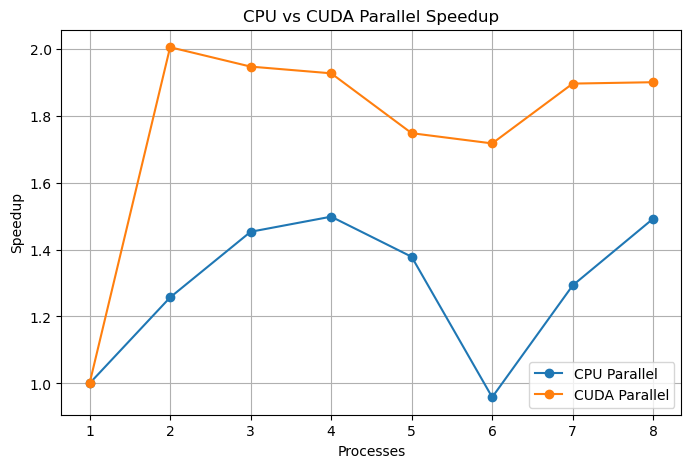

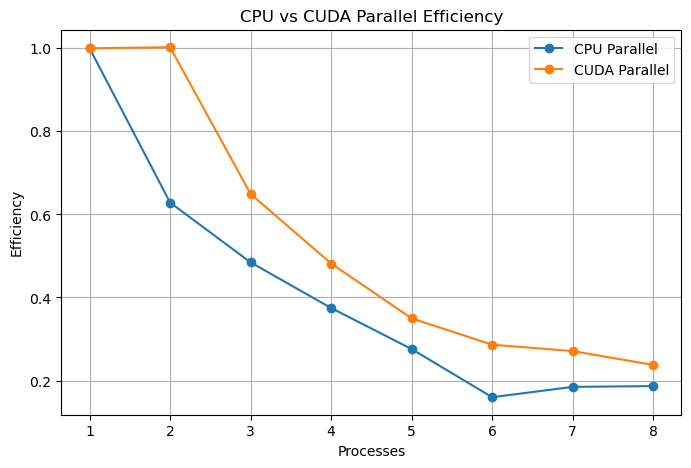

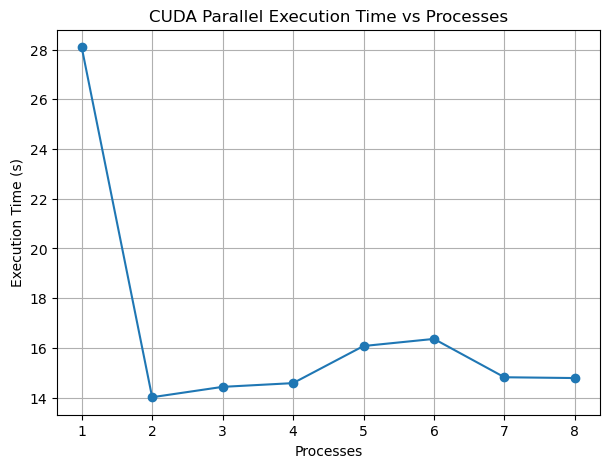

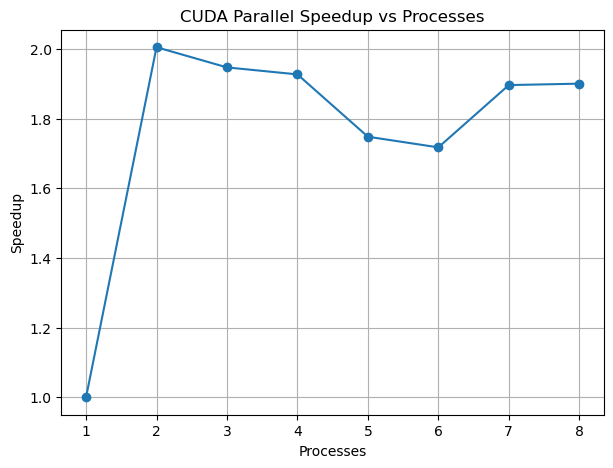

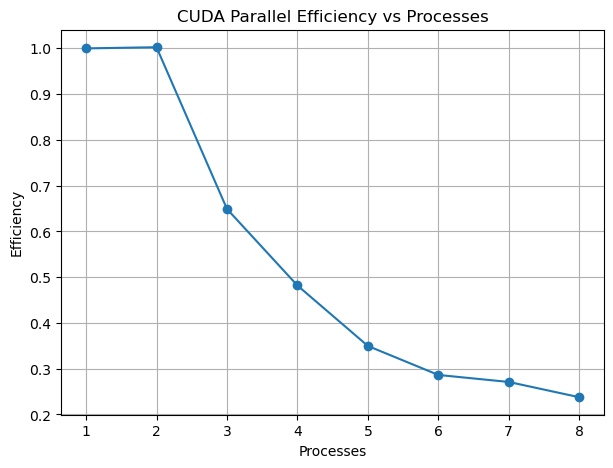

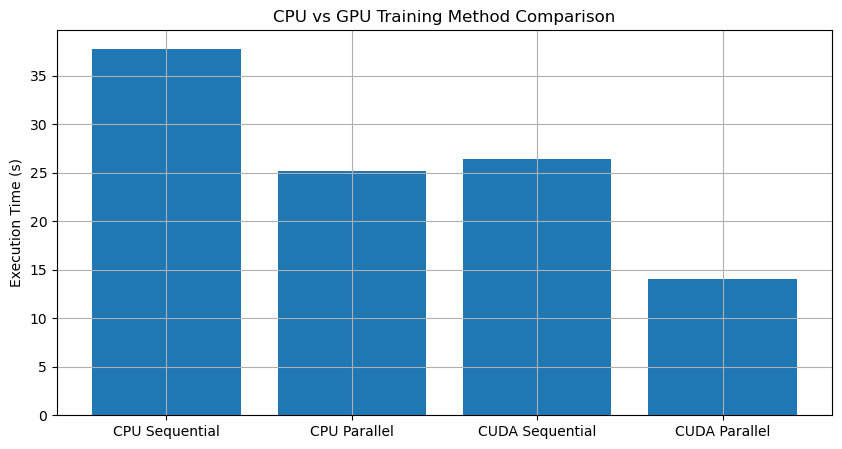

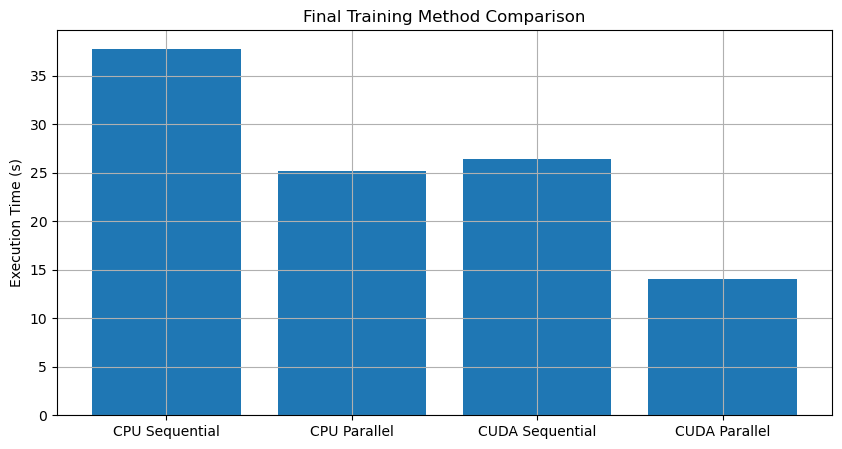

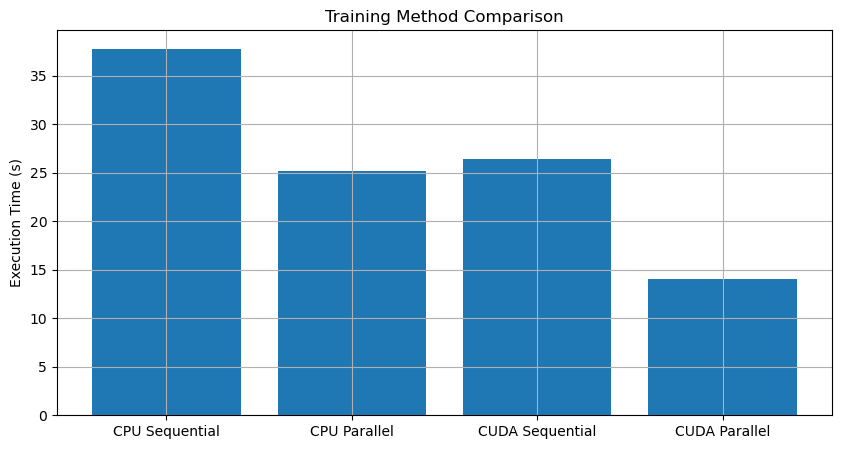

All Graphs Generated Successfully


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../result/plots", exist_ok=True)

cpu_df = pd.read_csv("../result/metrics/final_results.csv")
cuda_df = pd.read_csv("../result/metrics/cuda_parallel_results.csv")

cpu_seq_time = cpu_df.loc[
    cpu_df["Processes"] == 1,
    "Execution Time"
].values[0]

cpu_parallel_time = cpu_df["Execution Time"].min()

cuda_seq_time = gpu_time

cuda_parallel_time = cuda_df["Execution Time"].min()

# =====================================================
# 1. CPU Sequential and Parallel Training Analysis
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Execution Time"],
    marker='o'
)
plt.xlabel("Processes")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Processes")
plt.grid(True)
plt.savefig("../result/plots/execution_time.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Speedup"],
    marker='o'
)
plt.xlabel("Processes")
plt.ylabel("Speedup")
plt.title("Speedup vs Processes")
plt.grid(True)
plt.savefig("../result/plots/speedup.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Efficiency"],
    marker='o'
)
plt.xlabel("Processes")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Processes")
plt.grid(True)
plt.savefig("../result/plots/efficiency.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Execution Time"],
    marker='o',
    linewidth=2,
    label="CPU Parallel"
)

plt.axhline(
    y=cpu_seq_time,
    linestyle='--',
    label="CPU Sequential"
)

plt.xlabel("Processes")
plt.ylabel("Execution Time (s)")
plt.title("CPU Sequential vs Parallel Execution Time")
plt.legend()
plt.grid(True)
plt.savefig("../result/plots/cpu_seq_vs_parallel_execution_time.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Speedup"],
    marker='o',
    linewidth=2,
    label="CPU Parallel"
)

plt.axhline(
    y=1.0,
    linestyle='--',
    label="CPU Sequential"
)

plt.xlabel("Processes")
plt.ylabel("Speedup")
plt.title("CPU Sequential vs Parallel Speedup")
plt.legend()
plt.grid(True)
plt.savefig("../result/plots/cpu_seq_vs_parallel_speedup.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Efficiency"],
    marker='o',
    linewidth=2,
    label="CPU Parallel"
)

plt.axhline(
    y=1.0,
    linestyle='--',
    label="CPU Sequential"
)

plt.xlabel("Processes")
plt.ylabel("Efficiency")
plt.title("CPU Sequential vs Parallel Efficiency")
plt.legend()
plt.grid(True)
plt.savefig("../result/plots/cpu_seq_vs_parallel_efficiency.png")
plt.show()

# =====================================================
# 2. CPU Sequential vs CUDA Sequential Analysis
# =====================================================

methods = [
    "CPU Sequential",
    "CUDA Sequential"
]

times = [
    cpu_seq_time,
    cuda_seq_time
]

plt.figure(figsize=(7,5))
plt.bar(
    methods,
    times
)

plt.ylabel("Execution Time (s)")
plt.title("CPU Sequential vs CUDA Sequential")
plt.grid(True)
plt.savefig("../result/plots/cpu_seq_vs_cuda_seq.png")
plt.show()

# =====================================================
# 3. CPU Parallel vs CUDA Parallel Analysis
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Execution Time"],
    marker='o',
    label="CPU Parallel"
)

plt.plot(
    cuda_df["Processes"],
    cuda_df["Execution Time"],
    marker='o',
    label="CUDA Parallel"
)

plt.xlabel("Processes")
plt.ylabel("Execution Time (s)")
plt.title("CPU vs CUDA Parallel Execution Time")
plt.legend()
plt.grid(True)
plt.savefig("../result/plots/cpu_vs_cuda_execution_time.png")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Speedup"],
    marker='o',
    label="CPU Parallel"
)

plt.plot(
    cuda_df["Processes"],
    cuda_df["Speedup"],
    marker='o',
    label="CUDA Parallel"
)

plt.xlabel("Processes")
plt.ylabel("Speedup")
plt.title("CPU vs CUDA Parallel Speedup")
plt.legend()
plt.grid(True)
plt.savefig("../result/plots/cpu_vs_cuda_speedup.png")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(
    cpu_df["Processes"],
    cpu_df["Efficiency"],
    marker='o',
    label="CPU Parallel"
)

plt.plot(
    cuda_df["Processes"],
    cuda_df["Efficiency"],
    marker='o',
    label="CUDA Parallel"
)

plt.xlabel("Processes")
plt.ylabel("Efficiency")
plt.title("CPU vs CUDA Parallel Efficiency")
plt.legend()
plt.grid(True)
plt.savefig("../result/plots/cpu_vs_cuda_efficiency.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    cuda_df["Processes"],
    cuda_df["Execution Time"],
    marker='o'
)

plt.xlabel("Processes")
plt.ylabel("Execution Time (s)")
plt.title("CUDA Parallel Execution Time vs Processes")
plt.grid(True)
plt.savefig("../result/plots/cuda_execution_time.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    cuda_df["Processes"],
    cuda_df["Speedup"],
    marker='o'
)

plt.xlabel("Processes")
plt.ylabel("Speedup")
plt.title("CUDA Parallel Speedup vs Processes")
plt.grid(True)
plt.savefig("../result/plots/cuda_speedup.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    cuda_df["Processes"],
    cuda_df["Efficiency"],
    marker='o'
)

plt.xlabel("Processes")
plt.ylabel("Efficiency")
plt.title("CUDA Parallel Efficiency vs Processes")
plt.grid(True)
plt.savefig("../result/plots/cuda_efficiency.png")
plt.show()

# =====================================================
# 4. Overall Training Method Comparison
# =====================================================

methods = [
    "CPU Sequential",
    "CPU Parallel",
    "CUDA Sequential",
    "CUDA Parallel"
]

times = [
    cpu_seq_time,
    cpu_parallel_time,
    cuda_seq_time,
    cuda_parallel_time
]

plt.figure(figsize=(10,5))
plt.bar(
    methods,
    times
)

plt.ylabel("Execution Time (s)")
plt.title("CPU vs GPU Training Method Comparison")
plt.grid(True)
plt.savefig("../result/plots/cpu_gpu_training_comparison.png")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(
    methods,
    times
)

plt.ylabel("Execution Time (s)")
plt.title("Final Training Method Comparison")
plt.grid(True)
plt.savefig("../result/plots/final_training_method_comparison.png")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(
    methods,
    times
)

plt.ylabel("Execution Time (s)")
plt.title("Training Method Comparison")
plt.grid(True)
plt.savefig("../result/plots/training_method_comparison.png")
plt.show()

print("All Graphs Generated Successfully")

In [26]:
import pandas as pd
import os

os.makedirs("../result/metrics", exist_ok=True)

cpu_df = pd.read_csv(
    "../result/metrics/final_results.csv"
)

cuda_df = pd.read_csv(
    "../result/metrics/cuda_parallel_results.csv"
)

cpu_seq_time = cpu_df.loc[
    cpu_df["Processes"] == 1,
    "Execution Time"
].values[0]

cpu_parallel_time = cpu_df["Execution Time"].min()

cuda_seq_time = gpu_time

cuda_parallel_time = cuda_df["Execution Time"].min()

summary_results = pd.DataFrame({
    "Training Method": [
        "CPU Sequential",
        "CPU Parallel",
        "CUDA Sequential",
        "CUDA Parallel"
    ],
    "Execution Time": [
        cpu_seq_time,
        cpu_parallel_time,
        cuda_seq_time,
        cuda_parallel_time
    ]
})

all_results = pd.concat(
    [
        cpu_df.assign(Type="CPU"),
        cuda_df.assign(Type="CUDA")
    ],
    ignore_index=True
)

summary_results.to_csv(
    "../result/metrics/final_training_summary.csv",
    index=False
)

all_results.to_csv(
    "../result/metrics/all_results_combined.csv",
    index=False
)

print("Summary Results:\n")
print(summary_results)

print("\nAll Results:\n")
print(all_results)

print("\nCSV Files Saved Successfully")

Summary Results:

   Training Method  Execution Time
0   CPU Sequential       37.774798
1     CPU Parallel       25.208874
2  CUDA Sequential       26.440849
3    CUDA Parallel       14.014052

All Results:

    Processes  Execution Time   Speedup  Efficiency  Type
0           1       37.774798  1.000000    1.000000   CPU
1           2       30.051552  1.257000    0.628500   CPU
2           3       25.992655  1.453287    0.484429   CPU
3           4       25.208874  1.498472    0.374618   CPU
4           5       27.402916  1.378496    0.275699   CPU
5           6       39.403584  0.958664    0.159777   CPU
6           7       29.215515  1.292970    0.184710   CPU
7           8       25.307035  1.492660    0.186582   CPU
8           1       28.098803  1.000000    1.000000  CUDA
9           2       14.014052  2.005045    1.002522  CUDA
10          3       14.431025  1.947111    0.649037  CUDA
11          4       14.581478  1.927020    0.481755  CUDA
12          5       16.074448  1.74804

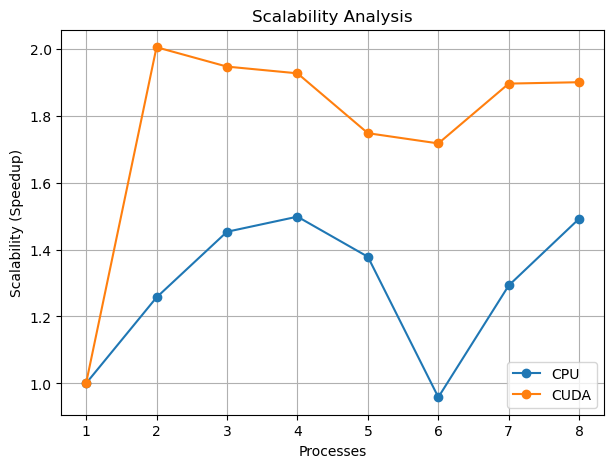

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    cpu_df["Processes"],
    cpu_df["Speedup"],
    marker='o',
    label="CPU"
)

plt.plot(
    cuda_df["Processes"],
    cuda_df["Speedup"],
    marker='o',
    label="CUDA"
)

plt.xlabel("Processes")

plt.ylabel("Scalability (Speedup)")

plt.title("Scalability Analysis")

plt.legend()

plt.grid(True)

plt.savefig(
    "../result/plots/scalability_analysis.png"
)

plt.show()

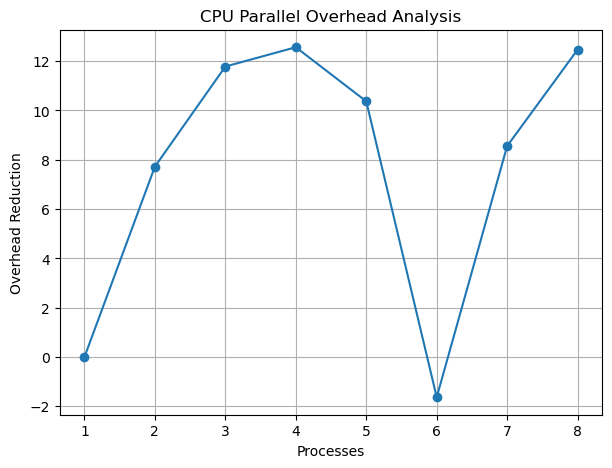

In [28]:
cpu_overhead = cpu_seq_time - cpu_df["Execution Time"]

plt.figure(figsize=(7,5))

plt.plot(
    cpu_df["Processes"],
    cpu_overhead,
    marker='o'
)

plt.xlabel("Processes")

plt.ylabel("Overhead Reduction")

plt.title("CPU Parallel Overhead Analysis")

plt.grid(True)

plt.savefig(
    "../result/plots/overhead_analysis.png"
)

plt.show()

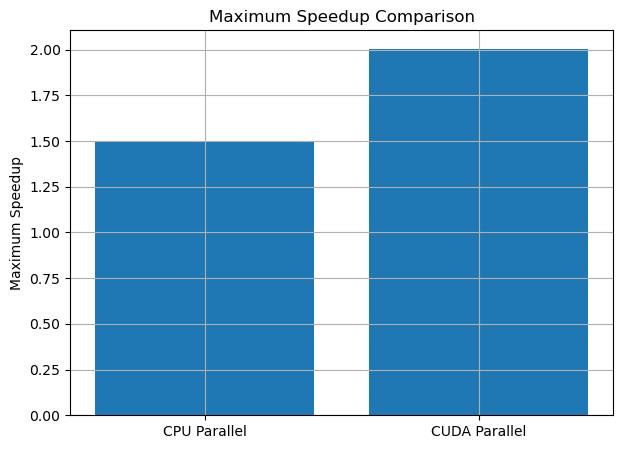

In [29]:
methods = [
    "CPU Parallel",
    "CUDA Parallel"
]

speedups = [
    cpu_df["Speedup"].max(),
    cuda_df["Speedup"].max()
]

plt.figure(figsize=(7,5))

plt.bar(
    methods,
    speedups
)

plt.ylabel("Maximum Speedup")

plt.title("Maximum Speedup Comparison")

plt.grid(True)

plt.savefig(
    "../result/plots/max_speedup_comparison.png"
)

plt.show()

          Component                                      Specification
0  Operating System                                         Windows 10
1         Processor  AMD64 Family 23 Model 96 Stepping 1, AuthenticAMD
2          RAM (GB)                                              15.37
3               GPU                            NVIDIA GeForce GTX 1650
4    Python Version                                            3.10.20
5   PyTorch Version                                        2.5.1+cu121
6    CUDA Available                                               True


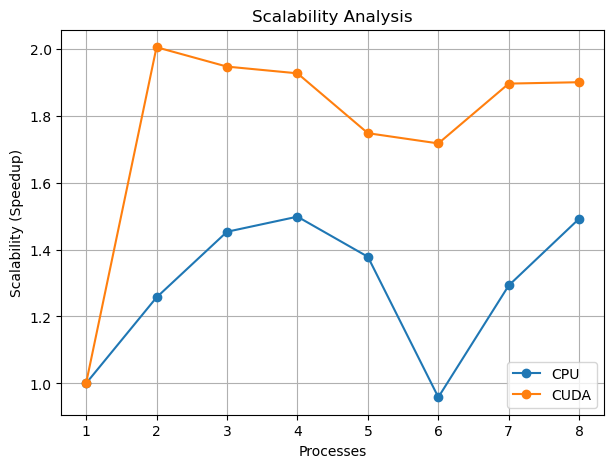

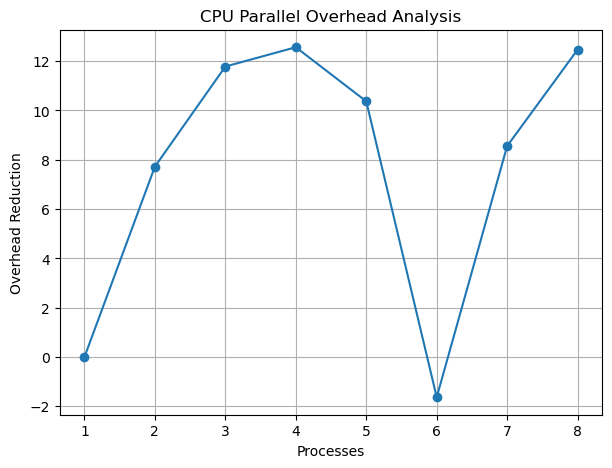

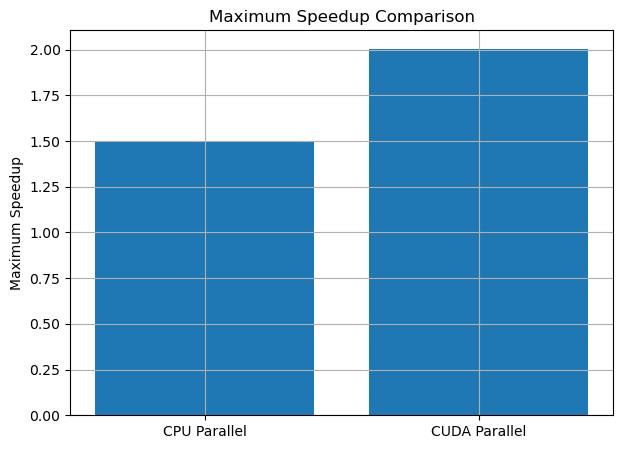


Final Summary Results:

   Training Method  Execution Time
0   CPU Sequential       37.774798
1     CPU Parallel       25.208874
2  CUDA Sequential       26.440849
3    CUDA Parallel       14.014052

Amdahl Analysis:

   Processes  Observed Speedup
0          1          1.000000
1          2          1.257000
2          3          1.453287
3          4          1.498472
4          5          1.378496
5          6          0.958664
6          7          1.292970
7          8          1.492660

Additional Analysis Completed Successfully


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import platform
import torch
import os
import psutil

os.makedirs("../result/metrics", exist_ok=True)
os.makedirs("../result/plots", exist_ok=True)



system_info = pd.DataFrame({
    "Component": [
        "Operating System",
        "Processor",
        "RAM (GB)",
        "GPU",
        "Python Version",
        "PyTorch Version",
        "CUDA Available"
    ],
    "Specification": [
        platform.system() + " " + platform.release(),
        platform.processor(),
        round(psutil.virtual_memory().total / (1024**3), 2),
        torch.cuda.get_device_name(0),
        platform.python_version(),
        torch.__version__,
        torch.cuda.is_available()
    ]
})

print(system_info)

system_info.to_csv(
    "../result/metrics/system_configuration.csv",
    index=False
)


cpu_df = pd.read_csv(
    "../result/metrics/final_results.csv"
)

cuda_df = pd.read_csv(
    "../result/metrics/cuda_parallel_results.csv"
)

cpu_seq_time = cpu_df.loc[
    cpu_df["Processes"] == 1,
    "Execution Time"
].values[0]

cpu_parallel_time = cpu_df["Execution Time"].min()

cuda_seq_time = gpu_time

cuda_parallel_time = cuda_df["Execution Time"].min()


plt.figure(figsize=(7,5))

plt.plot(
    cpu_df["Processes"],
    cpu_df["Speedup"],
    marker='o',
    label="CPU"
)

plt.plot(
    cuda_df["Processes"],
    cuda_df["Speedup"],
    marker='o',
    label="CUDA"
)

plt.xlabel("Processes")

plt.ylabel("Scalability (Speedup)")

plt.title("Scalability Analysis")

plt.legend()

plt.grid(True)

plt.savefig(
    "../result/plots/scalability_analysis.png"
)

plt.show()


cpu_overhead = cpu_seq_time - cpu_df["Execution Time"]

plt.figure(figsize=(7,5))

plt.plot(
    cpu_df["Processes"],
    cpu_overhead,
    marker='o'
)

plt.xlabel("Processes")

plt.ylabel("Overhead Reduction")

plt.title("CPU Parallel Overhead Analysis")

plt.grid(True)

plt.savefig(
    "../result/plots/overhead_analysis.png"
)

plt.show()



methods = [
    "CPU Parallel",
    "CUDA Parallel"
]

speedups = [
    cpu_df["Speedup"].max(),
    cuda_df["Speedup"].max()
]

plt.figure(figsize=(7,5))

plt.bar(
    methods,
    speedups
)

plt.ylabel("Maximum Speedup")

plt.title("Maximum Speedup Comparison")

plt.grid(True)

plt.savefig(
    "../result/plots/max_speedup_comparison.png"
)

plt.show()


summary_results = pd.DataFrame({
    "Training Method": [
        "CPU Sequential",
        "CPU Parallel",
        "CUDA Sequential",
        "CUDA Parallel"
    ],
    "Execution Time": [
        cpu_seq_time,
        cpu_parallel_time,
        cuda_seq_time,
        cuda_parallel_time
    ]
})

print("\nFinal Summary Results:\n")

print(summary_results)

summary_results.to_csv(
    "../result/metrics/final_training_summary.csv",
    index=False
)


amdahl_df = pd.DataFrame({
    "Processes": cpu_df["Processes"],
    "Observed Speedup": cpu_df["Speedup"]
})

amdahl_df.to_csv(
    "../result/metrics/amdahl_analysis.csv",
    index=False
)

print("\nAmdahl Analysis:\n")

print(amdahl_df)

print("\nAdditional Analysis Completed Successfully")

In [34]:
import pandas as pd
import platform
import torch
import psutil
import os

os.makedirs("../result/metrics", exist_ok=True)


cpu_df = pd.read_csv(
    "../result/metrics/final_results.csv"
)

cuda_df = pd.read_csv(
    "../result/metrics/cuda_parallel_results.csv"
)


system_info = pd.DataFrame({
    "Category": ["System"] * 7,
    "Metric": [
        "Operating System",
        "Processor",
        "RAM (GB)",
        "GPU",
        "Python Version",
        "PyTorch Version",
        "CUDA Available"
    ],
    "Value": [
        platform.system() + " " + platform.release(),
        platform.processor(),
        round(psutil.virtual_memory().total / (1024**3), 2),
        torch.cuda.get_device_name(0),
        platform.python_version(),
        torch.__version__,
        torch.cuda.is_available()
    ]
})



cpu_seq_time = cpu_df.loc[
    cpu_df["Processes"] == 1,
    "Execution Time"
].values[0]

cpu_parallel_time = cpu_df["Execution Time"].min()

cpu_summary = pd.DataFrame({
    "Category": ["CPU Results"] * 4,
    "Metric": [
        "CPU Sequential Time",
        "Best CPU Parallel Time",
        "Maximum CPU Speedup",
        "Maximum CPU Efficiency"
    ],
    "Value": [
        cpu_seq_time,
        cpu_parallel_time,
        cpu_df["Speedup"].max(),
        cpu_df["Efficiency"].max()
    ]
})


cuda_seq_time = gpu_time

cuda_parallel_time = cuda_df["Execution Time"].min()

cuda_summary = pd.DataFrame({
    "Category": ["CUDA Results"] * 4,
    "Metric": [
        "CUDA Sequential Time",
        "Best CUDA Parallel Time",
        "Maximum CUDA Speedup",
        "Maximum CUDA Efficiency"
    ],
    "Value": [
        cuda_seq_time,
        cuda_parallel_time,
        cuda_df["Speedup"].max(),
        cuda_df["Efficiency"].max()
    ]
})


comparison_df = pd.DataFrame({
    "Category": ["Final Comparison"] * 4,
    "Metric": [
        "CPU Sequential",
        "CPU Parallel",
        "CUDA Sequential",
        "CUDA Parallel"
    ],
    "Value": [
        cpu_seq_time,
        cpu_parallel_time,
        cuda_seq_time,
        cuda_parallel_time
    ]
})


amdahl_df = pd.DataFrame({
    "Category": ["Amdahl Analysis"] * len(cpu_df),
    "Metric": [
        f"Processes {p}"
        for p in cpu_df["Processes"]
    ],
    "Value": cpu_df["Speedup"]
})


final_csv = pd.concat(
    [
        system_info,
        cpu_summary,
        cuda_summary,
        comparison_df,
        amdahl_df
    ],
    ignore_index=True
)

final_csv.to_csv(
    "../result/metrics/final_complete_results.csv",
    index=False
)

print(final_csv)

print("\nAll Results Added To CSV Successfully")

            Category                   Metric  \
0             System         Operating System   
1             System                Processor   
2             System                 RAM (GB)   
3             System                      GPU   
4             System           Python Version   
5             System          PyTorch Version   
6             System           CUDA Available   
7        CPU Results      CPU Sequential Time   
8        CPU Results   Best CPU Parallel Time   
9        CPU Results      Maximum CPU Speedup   
10       CPU Results   Maximum CPU Efficiency   
11      CUDA Results     CUDA Sequential Time   
12      CUDA Results  Best CUDA Parallel Time   
13      CUDA Results     Maximum CUDA Speedup   
14      CUDA Results  Maximum CUDA Efficiency   
15  Final Comparison           CPU Sequential   
16  Final Comparison             CPU Parallel   
17  Final Comparison          CUDA Sequential   
18  Final Comparison            CUDA Parallel   
19   Amdahl Analysis